# Sparse polynomial regression and LASSO for AAA CFD data

*Leif Rune Hellevik – Department of structural engineering, Norwegian University of Science and Technology (NTNU)*


## Motivation

In this notebook, we demonstrate how a multivariate polynomial regression
model can provide a fast and interpretable approximation to complex
relationships represented by CFD or FEM simulations, or observed in
experimental measurements.

However, a full polynomial basis may contain many unnecessary terms.
We investigate how LASSO can identify a sparse model that retains the
most influential terms while preserving good predictive accuracy.



## Synthetic example and polynomial notation

We use three nondimensional inputs, each scaled to $[-1,1]$:

$$
x_1 = Re^*, \qquad x_2 = D_{\mathrm{AAA}}^*, \qquad x_3 = D_d/D_m.
$$

The synthetic response is generated from the sparse cubic model

$$
\Delta p^* = 2 + 1.5x_1 + 3x_2 - 1.2x_3
+ 2x_1x_2 - 1.5x_2^2 + 0.8x_1x_3^2.
$$

More generally, a polynomial of total degree at most three can be written in classical index notation as

$$
\Delta p^*(\mathbf{x}) = a_0
+ \sum_{i=1}^{3} a_i x_i
+ \sum_{1 \leq i \leq j \leq 3} a_{ij} x_i x_j
+ \sum_{1 \leq i \leq j \leq k \leq 3} a_{ijk} x_i x_j x_k.
$$

Each product of input variables is called a **monomial**. A monomial may contain repeated factors of the same input, such as $x_2^2$, factors from different inputs, such as $x_1x_2$, or both, such as $x_1x_3^2$. A polynomial is a sum of monomials, each multiplied by a coefficient.

Repeated indices identify repeated factors: $a_{12}$ multiplies $x_1x_2$, $a_{22}$ multiplies $x_2^2$, and $a_{133}$ multiplies $x_1x_3^2$. Since the model is sparse, we only store the nonzero coefficients.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters that are easy to change
N = 200       # number of synthetic observations
sigma = 0.20  # standard deviation of the added Gaussian noise
seed = 42     # random seed: same value reproduces the same data
degree = 3    # maximum total degree in the candidate polynomial basis

# Nonzero coefficients in classical index notation
# "12" means a_12 (x1*x2), "133" means a_133 (x1*x3^2)
a = {
    "0":   2.0,
    "1":   1.5,
    "2":   3.0,
    "3":  -1.2,
    "12":  2.0,
    "22": -1.5,
    "133": 0.8,
}

In [2]:
def polynomial(X, a):
    """Evaluate the polynomial for all rows of X.

    X[:, 0], X[:, 1], and X[:, 2] contain x1, x2, and x3.
    Each key i lists the factors in one monomial. For example,
    i = "12" represents x1*x2 and i = "133" represents x1*x3*x3.
    """
    # Every observation starts with the constant term a_0.
    y = np.full(X.shape[0], a.get("0", 0.0))

    # i is an index string such as "1", "22", or "133";
    # ai is the corresponding coefficient a_i, a_22, or a_133.
    for i, ai in a.items():
        if i == "0":
            continue  # the constant term is already included above

        # Construct the monomial specified by i.
        # Repeated indices create powers: "22" -> x2*x2.
        monomial = np.ones(X.shape[0])
        for j in i:
            column = int(j) - 1  # mathematical index 1, 2, 3 -> column 0, 1, 2
            monomial *= X[:, column]

        # Add a_i times its monomial to the polynomial.
        y += ai * monomial

    return y

In [3]:
rng = np.random.default_rng(seed)
X = rng.uniform(-1, 1, size=(N, 3))
x1, x2, x3 = X.T

dp_exact = polynomial(X, a)
noise = rng.normal(0, sigma, size=N)
dp = dp_exact + noise

print(f"Response range: {dp.min():.3f} to {dp.max():.3f}")
print(f"Realized noise standard deviation: {noise.std(ddof=1):.3f}")

Response range: -3.075 to 6.854
Realized noise standard deviation: 0.211


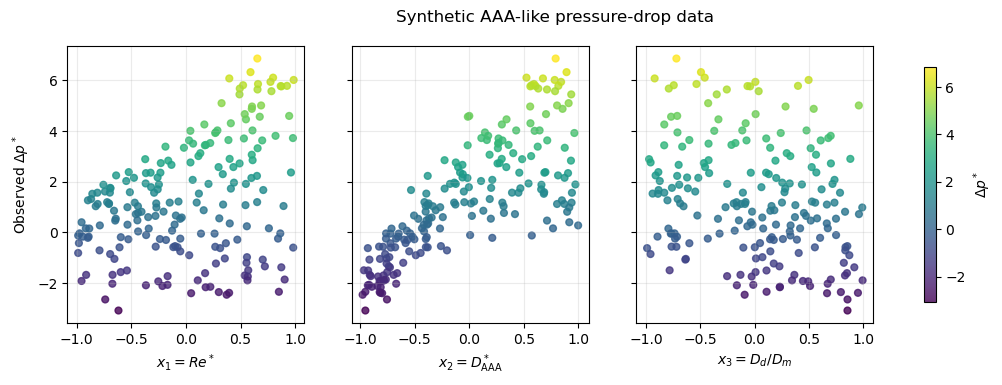

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
labels = [r"$x_1 = Re^*$", r"$x_2 = D_{\mathrm{AAA}}^*$", r"$x_3 = D_d/D_m$"]

for j, ax in enumerate(axes):
    sc = ax.scatter(X[:, j], dp, c=dp, cmap="viridis", s=24, alpha=0.8)
    ax.set_xlabel(labels[j])
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"Observed $\Delta p^*$")
fig.colorbar(sc, ax=axes, label=r"$\Delta p^*$", shrink=0.85)
fig.suptitle("Synthetic AAA-like pressure-drop data")
plt.show()

## Candidate polynomial basis through degree 3

We now pretend that the generating polynomial is unknown. We therefore
include every monomial of total degree at most three as a possible model
component.

For one observation $\mathbf{x}=(x_1,x_2,x_3)$, collect the 19
nonconstant monomials in the vector

$$
\boldsymbol{\phi}(\mathbf{x}) =
\begin{bmatrix}
x_1 & x_2 & x_3 & x_1^2 & x_1x_2 & \cdots & x_3^3
\end{bmatrix}^{T}.
$$

For all $N$ observations, these vectors are stacked as rows in the
**design matrix**

$$
\Phi =
\begin{bmatrix}
\boldsymbol{\phi}(\mathbf{x}^{(1)})^T \\
\boldsymbol{\phi}(\mathbf{x}^{(2)})^T \\
\vdots \\
\boldsymbol{\phi}(\mathbf{x}^{(N)})^T
\end{bmatrix}.
$$

Thus, each row represents one observation and each column represents one
candidate monomial. `PolynomialFeatures` constructs this matrix from `X`.
The constant monomial is omitted because the regression model estimates
the intercept separately.

In [5]:
from sklearn.preprocessing import PolynomialFeatures

# PolynomialFeatures generates every monomial in x1, x2, and x3
# whose total degree is at most "degree".
# The constant monomial 1 is omitted because the regression model
# estimates the intercept separately.
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Phi is the design matrix: rows are observations and columns are monomials.
Phi = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(["x1", "x2", "x3"])

print(f"Polynomial degree: {degree}")
print(f"Design matrix shape: {Phi.shape}")
print("Candidate terms:")
print(", ".join(feature_names))

Polynomial degree: 3
Design matrix shape: (200, 19)
Candidate terms:
x1, x2, x3, x1^2, x1 x2, x1 x3, x2^2, x2 x3, x3^2, x1^3, x1^2 x2, x1^2 x3, x1 x2^2, x1 x2 x3, x1 x3^2, x2^3, x2^2 x3, x2 x3^2, x3^3


## Ordinary least squares on the full cubic basis

The design matrix $\Phi$ is now known. The unknown quantities are the
intercept $\beta_0$ and the coefficient vector $\boldsymbol{\beta}$,
which assigns one coefficient to each column of $\Phi$.

For one observation, the fitted polynomial is

$$
\widehat{\Delta p^*}
=
\beta_0 + \boldsymbol{\phi}(\mathbf{x})^T\boldsymbol{\beta}.
$$

Ordinary least squares estimates all 19 coefficients simultaneously by
minimizing

$$
\min_{\beta_0,\boldsymbol{\beta}}
\sum_{i=1}^{N}
\left[
y_i -
\left(
\beta_0 +
\boldsymbol{\phi}(\mathbf{x}^{(i)})^T\boldsymbol{\beta}
\right)
\right]^2.
$$

OLS does not encourage sparsity. With noisy data, coefficients of
monomials that are truly absent will generally be small but nonzero.
Because this is a synthetic example, we can compare the fitted
coefficients directly with the known ground truth.

In [6]:
from sklearn.linear_model import LinearRegression

# Create an ordinary least-squares regression object, with the estimated intercept and coefficients.
ols = LinearRegression()
ols.fit(Phi, dp)
dp_hat_ols = ols.predict(Phi)

In [7]:
# Administrative code: connect sklearn's exponent representation
# (for example [1, 0, 2]) to our index notation "133".
def coefficient_index(powers):
    return "".join(str(j + 1) * int(power) for j, power in enumerate(powers))

true_intercept = a.get("0", 0.0)
true_coef = np.array([
    a.get(coefficient_index(powers), 0.0)
    for powers in poly.powers_
])

### OLS diagnostics and coefficient plot

True intercept:   2.000  OLS intercept:   1.983
Training RMSE: 0.2063
Training R^2: 0.99183
Nonzero OLS terms: 19 / 19


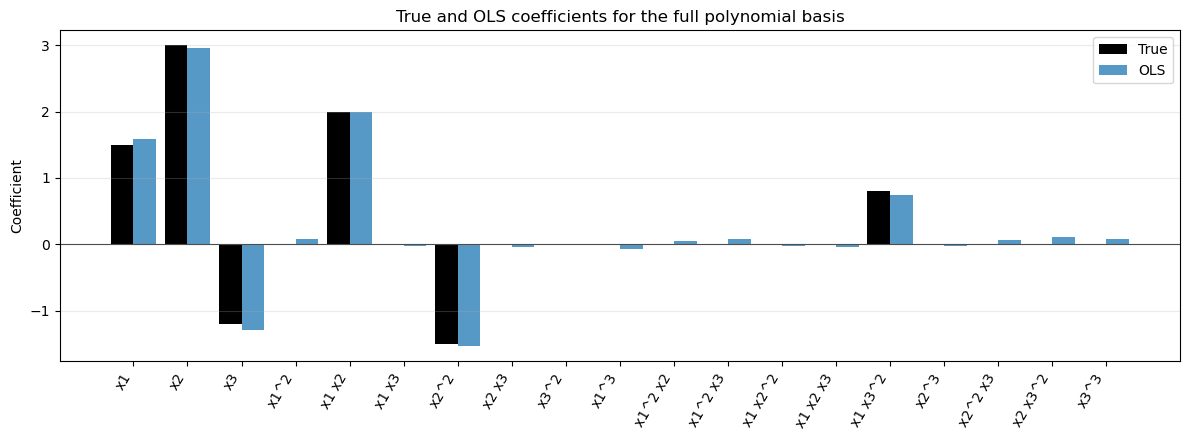

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_ols = np.sqrt(mean_squared_error(dp, dp_hat_ols))
print(f"True intercept: {true_intercept:7.3f}  OLS intercept: {ols.intercept_:7.3f}")
print(f"Training RMSE: {rmse_ols:.4f}")
print(f"Training R^2: {r2_score(dp, dp_hat_ols):.5f}")
print(f"Nonzero OLS terms: {np.count_nonzero(np.abs(ols.coef_) > 1e-12)} / {len(feature_names)}")

show_coefficients = False

if show_coefficients:
    print("\nCoefficient comparison")
    print(f"{'term':12s} {'true':>9s} {'OLS':>9s}")
    for name, truth, estimate in zip(feature_names, true_coef, ols.coef_):
        print(f"{name:12s} {truth:9.3f} {estimate:9.3f}")

positions = np.arange(len(feature_names))
width = 0.42
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(positions - width/2, true_coef, width, label="True", color="black")
ax.bar(positions + width/2, ols.coef_, width, label="OLS", color="tab:blue", alpha=0.75)
ax.axhline(0, color="0.3", linewidth=0.8)
ax.set_xticks(positions, feature_names, rotation=60, ha="right")
ax.set_ylabel("Coefficient")
ax.set_title("True and OLS coefficients for the full polynomial basis")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## LASSO with a fixed regularization strength

LASSO adds an $L_1$ penalty to the least-squares objective:

$$
\min_{\beta_0,\boldsymbol{\beta}}
\left[
\frac{1}{2N}\sum_{i=1}^{N}
\left(y_i-\beta_0-\boldsymbol{\phi}(\mathbf{x}_i)^T\boldsymbol{\beta}\right)^2
+\alpha\sum_{j=1}^{19}|\beta_j|
\right].
$$

Increasing $\alpha$ strengthens the penalty. Unlike OLS, LASSO can set coefficients exactly to zero. We first choose $\alpha=0.02$ manually so that we can inspect its effect before using cross-validation.

In [9]:
from sklearn.linear_model import Lasso

alpha = 0.02  # regularization strength

# Create a LASSO regression object.
lasso = Lasso(alpha=alpha)

# Estimate the intercept and polynomial coefficients.
lasso.fit(Phi, dp)

# Evaluate the fitted model.
dp_hat_lasso = lasso.predict(Phi)

In [10]:
# LASSO should produce exact zeros, apart from possible numerical round-off.
zero_tol = 1e-10
active = np.abs(lasso.coef_) > zero_tol

rmse_lasso = np.sqrt(mean_squared_error(dp, dp_hat_lasso))

print(f"alpha: {alpha}")
print(f"LASSO intercept: {lasso.intercept_:.3f}")
print(f"Training RMSE: {rmse_lasso:.4f} (OLS: {rmse_ols:.4f})")
print(f"Training R^2: {r2_score(dp, dp_hat_lasso):.5f}")
print(f"Retained terms: {active.sum()} / {len(feature_names)}")

alpha: 0.02
LASSO intercept: 1.917
Training RMSE: 0.2571 (OLS: 0.2063)
Training R^2: 0.98731
Retained terms: 6 / 19


### Output coefficents

In [11]:
show_coefficients = False

if show_coefficients:
    print("\nRetained coefficients")
    print(f"{'term':12s} {'true':>9s} {'LASSO':>9s}")

    for name, truth, estimate in zip(
        feature_names[active],
        true_coef[active],
        lasso.coef_[active]
    ):
        print(f"{name:12s} {truth:9.3f} {estimate:9.3f}")

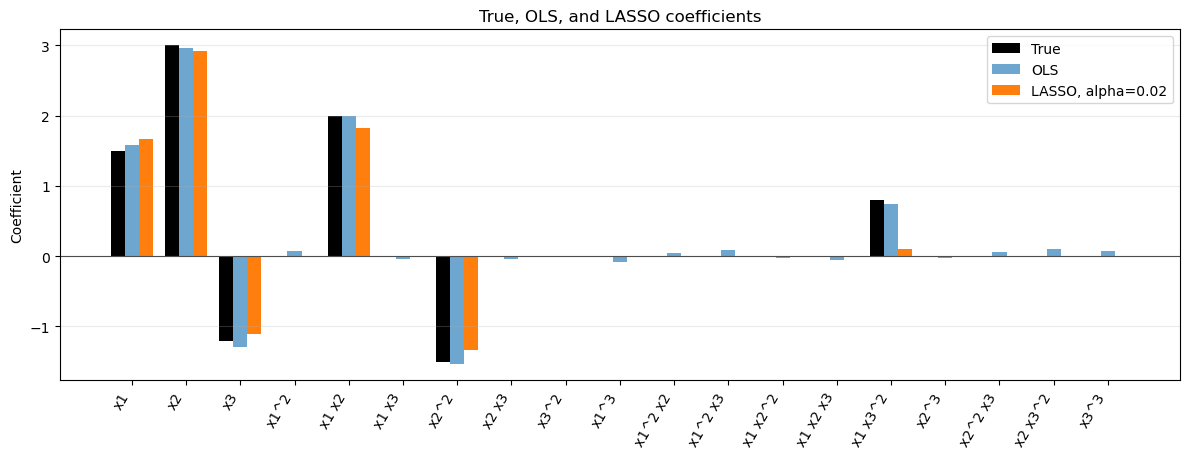

In [12]:
width = 0.26

fig, ax = plt.subplots(figsize=(12, 4.7))
ax.bar(positions - width, true_coef, width,
       label="True", color="black")
ax.bar(positions, ols.coef_, width,
       label="OLS", color="tab:blue", alpha=0.65)
ax.bar(positions + width, lasso.coef_, width,
       label=f"LASSO, alpha={alpha}", color="tab:orange")

ax.axhline(0, color="0.3", linewidth=0.8)
ax.set_xticks(positions, feature_names, rotation=60, ha="right")
ax.set_ylabel("Coefficient")
ax.set_title("True, OLS, and LASSO coefficients")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Coefficient paths as $\alpha$ varies

A single value of $\alpha$ hides the main mechanism of LASSO. We therefore fit the model over a logarithmic grid of regularization strengths. At very small $\alpha$, the solution approaches OLS. As $\alpha$ increases, coefficients shrink and eventually become exactly zero.

The paths also reveal a key trade-off: stronger regularization produces a simpler model, but increases the training error and biases the retained coefficients toward zero.

In [13]:
# Regularization strengths, from weak to strong regularization.
alphas = np.logspace(-4, 0, 140)

# One row of coef_path for each value of alpha.
coef_path = np.zeros((len(alphas), len(feature_names)))

for i, alpha_i in enumerate(alphas):
    model = Lasso(alpha=alpha_i)
    model.fit(Phi, dp)
    coef_path[i] = model.coef_

In [14]:
alphas = np.logspace(-4, 0, 140)

coef_path = np.zeros((len(alphas), len(feature_names)))
rmse_path = np.zeros(len(alphas))
n_terms_path = np.zeros(len(alphas), dtype=int)

for i, alpha_i in enumerate(alphas):
    lasso_i = Lasso(alpha=alpha_i)
    lasso_i.fit(Phi, dp)

    coef_path[i] = lasso_i.coef_

    dp_hat_i = lasso_i.predict(Phi)
    rmse_path[i] = np.sqrt(
        mean_squared_error(dp, dp_hat_i)
    )
    n_terms_path[i] = np.count_nonzero(
        np.abs(lasso_i.coef_) > zero_tol
    )

### Coefficient paths and the sparsity–fit trade-off

The left panel shows how each coefficient changes as the regularization
strength increases. The right panel compares model complexity with
training error.

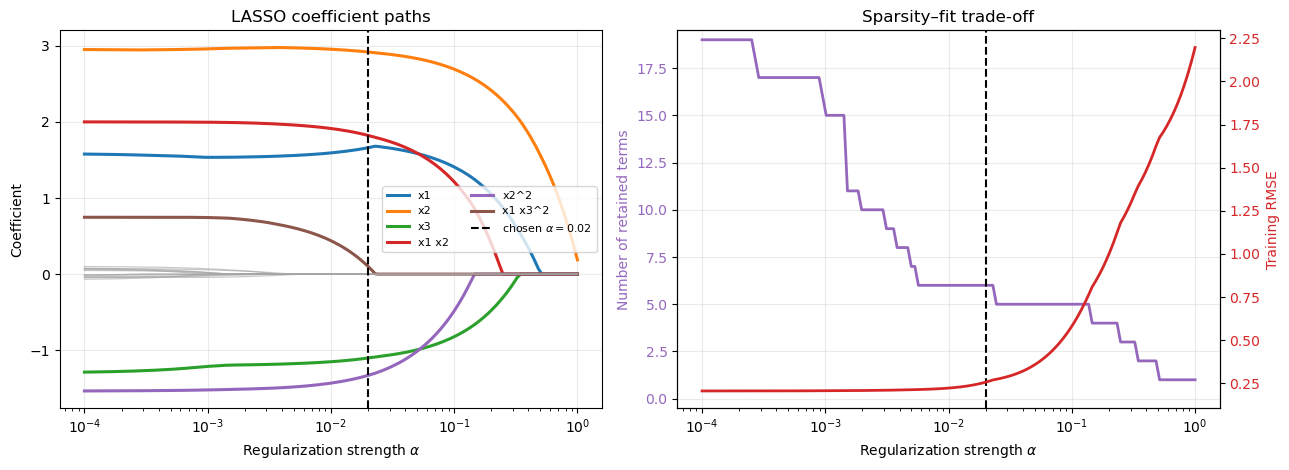

In [15]:
true_mask = true_coef != 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Coefficient paths
for j, name in enumerate(feature_names):
    if true_mask[j]:
        axes[0].semilogx(
            alphas,
            coef_path[:, j],
            linewidth=2.2,
            label=name
        )
    else:
        axes[0].semilogx(
            alphas,
            coef_path[:, j],
            color="0.65",
            linewidth=0.9,
            alpha=0.6
        )

axes[0].axvline(
    alpha,
    color="black",
    linestyle="--",
    label=fr"chosen $\alpha={alpha}$"
)
axes[0].set_xlabel(r"Regularization strength $\alpha$")
axes[0].set_ylabel("Coefficient")
axes[0].set_title("LASSO coefficient paths")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)


# Number of retained terms
axes[1].semilogx(
    alphas,
    n_terms_path,
    color="tab:purple",
    linewidth=2
)
axes[1].axvline(alpha, color="black", linestyle="--")
axes[1].set_xlabel(r"Regularization strength $\alpha$")
axes[1].set_ylabel(
    "Number of retained terms",
    color="tab:purple"
)
axes[1].tick_params(axis="y", labelcolor="tab:purple")
axes[1].set_ylim(-0.5, len(feature_names) + 0.5)
axes[1].grid(alpha=0.25)


# Training error on the second vertical axis
ax_rmse = axes[1].twinx()
ax_rmse.semilogx(
    alphas,
    rmse_path,
    color="tab:red",
    linewidth=2
)
ax_rmse.set_ylabel("Training RMSE", color="tab:red")
ax_rmse.tick_params(axis="y", labelcolor="tab:red")

axes[1].set_title("Sparsity–fit trade-off")

plt.tight_layout()
plt.show()

## Choosing $\alpha$ with cross-validation

Training error cannot choose the regularization strength because it always prefers the least constrained model. Instead, we split the data into five folds. For each candidate $\alpha$, the model is trained on four folds and evaluated on the held-out fold; this is repeated until every fold has served as validation data.

We select the $\alpha$ with the smallest mean validation mean-squared error. After selection, LassoCV refits the model on all observations using that value.

<details>
<summary><strong>Why use five-fold cross-validation?</strong></summary>

The training error cannot be used to select $\alpha$. Reducing the
penalty gives the model more freedom and will normally reduce the error
on the same observations used to estimate the coefficients. This does
not necessarily mean that the model will predict new observations well.

We therefore evaluate each candidate value of $\alpha$ using observations
that are temporarily excluded from model fitting. The data are divided
into $k$ folds. For each candidate $\alpha$:

1. fit the model using $k-1$ folds;
2. evaluate its prediction error on the remaining fold;
3. repeat until every fold has been used once for validation.

The mean validation error is

$$
E_{\mathrm{CV}}(\alpha)
=
\frac{1}{k}
\sum_{r=1}^{k}
E_r(\alpha),
$$

where $E_r(\alpha)$ is the error on validation fold $r$. We select the
value of $\alpha$ that gives the smallest mean validation error. Finally,
LASSO is refitted to all observations using the selected value.

Here we use $k=5$. With $N=200$ observations, each model is fitted using
approximately 160 observations and evaluated using the remaining 40.
Five folds provide a practical compromise between reliability and
computational cost.

</details>

In [20]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold


# Define five reproducible cross-validation folds.
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

# LassoCV tests the candidate alpha values using cross-validation.
lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv
)

# Select alpha and refit the model using all observations.
lasso_cv.fit(Phi, dp)

alpha_cv = lasso_cv.alpha_

In [17]:
dp_hat_cv = lasso_cv.predict(Phi)

active_cv = np.abs(lasso_cv.coef_) > zero_tol
rmse_cv_train = np.sqrt(
    mean_squared_error(dp, dp_hat_cv)
)

# mse_path_ contains one validation MSE for each alpha and fold.
mean_cv_mse = lasso_cv.mse_path_.mean(axis=1)
mean_cv_rmse = np.sqrt(mean_cv_mse)

best = np.argmin(mean_cv_mse)

print(f"Selected alpha: {alpha_cv:.6f}")
print(
    f"Retained terms: "
    f"{active_cv.sum()} / {len(feature_names)}"
)
print(f"Refit training RMSE: {rmse_cv_train:.4f}")
print(
    f"Cross-validation RMSE: "
    f"{mean_cv_rmse[best]:.4f}"
)

Selected alpha: 0.004088
Retained terms: 8 / 19
Refit training RMSE: 0.2120
Cross-validation RMSE: 0.2236


In [18]:
show_coefficients = False

if show_coefficients:
    print("\nRetained coefficients")
    print(f"{'term':12s} {'true':>9s} {'LassoCV':>9s}")

    for name, truth, estimate in zip(
        feature_names[active_cv],
        true_coef[active_cv],
        lasso_cv.coef_[active_cv]
    ):
        print(
            f"{name:12s} "
            f"{truth:9.3f} "
            f"{estimate:9.3f}"
        )

### Cross-validation error

The curve shows the validation error for each candidate value of
$\alpha$. The dashed line marks the value selected by `LassoCV`.

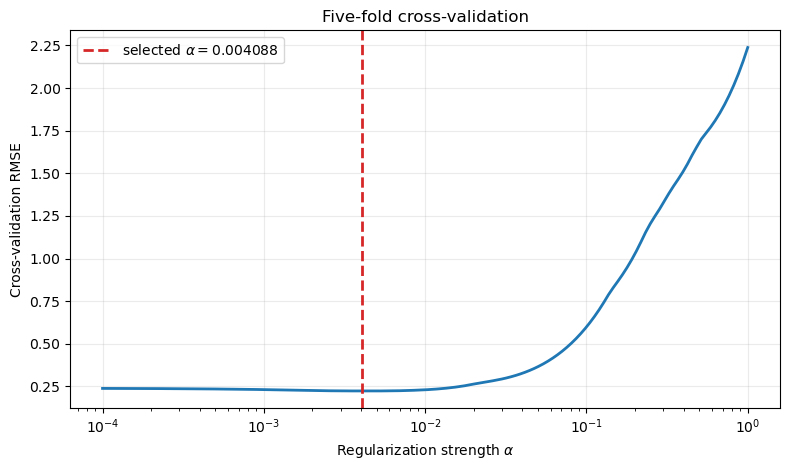

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.8))

ax.semilogx(
    lasso_cv.alphas_,
    mean_cv_rmse,
    color="tab:blue",
    linewidth=2
)

ax.axvline(
    alpha_cv,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=fr"selected $\alpha={alpha_cv:.4g}$"
)

ax.set_xlabel(r"Regularization strength $\alpha$")
ax.set_ylabel("Cross-validation RMSE")
ax.set_title("Five-fold cross-validation")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()